# Comparison between Present-Day TARDIS Spectrum and 2014 TARDIS Spectrum

In this notebook, we will compare the 2014 TARDIS Spectrum to the present-day (2026) TARDIS Spectrum over 3 different wavelength windows.  
These windows are regions of the spectrum that have no spectral features and remain mostly constant across the entire window.  
We will subtract the present-day spectrum from the 2014 spectrum, and then divide by the standard deviation of the window (as calculated in the kerz_sim_vs_PresTardis notebook).  
This will tell us how many of the residuals are at various distances from the expected value of the spectrum (assumed to be the mean value across the window) in standard deviations.  
We will then look at histograms for each window with this data, overlayed with a graph of the expected Normal Distribution for the data.  
If the distances of the residuals follows a normal distribution, we can conclude that the two simulations run very similarly, and that any differences in the spectra are likely due to random variation.   

In [1]:
# Import necessary libraries
import csv
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from tardis import run_tardis

Generate a TARDIS Spectrum

In [2]:
sim = run_tardis("kerz2014_tardis.yml")
spectrum = sim.spectrum_solver.spectrum_real_packets
spectrum_virtual = sim.spectrum_solver.spectrum_virtual_packets

Auto-detected VSCode environment


Auto-detected VSCode environment


Iterations:          0/? [00:00<?, ?it/s]

Packets:             0/? [00:00<?, ?it/s]

Initializing tabulator and plotly panel extensions for widgets to work


Embedding the final state for Jupyter environments


Rearrange data from TARDIS Spectrum so we have wavelengths in ascending order (useful for np.searchsorted() later on)

In [3]:
spec_wavs_pres = spectrum.wavelength.value.tolist()
spec_lums_pres = spectrum.luminosity_density_lambda.value.tolist()

spec_wavs_pres.reverse()
spec_lums_pres.reverse()
spec_wavs_pres = np.array(spec_wavs_pres)
spec_lums_pres = np.array(spec_lums_pres)


Read the data for the 2014 Spectrum from the .dat file found in the TARDIS Setups folder, then get wavelengths in ascending order

In [4]:
specdat = open("tardis_example_spec.dat", "r")
specdat.readline() # skip header

spec_wavs_2014 = []
spec_lums_2014 = []

for line in specdat:
    if line:
        parts = line.split()
        spec_wavs_2014.append(float(parts[0]))
        spec_lums_2014.append(float(parts[1]))


spec_wavs_2014.reverse()
spec_lums_2014.reverse()
spec_wavs_2014 = np.array(spec_wavs_2014)
spec_lums_2014 = np.array(spec_lums_2014)

Find the TARDIS seed from the yaml file

In [5]:
# Find the seed from the YAML file
fp = open("kerz2014_tardis.yml", mode='r')
lines = fp.readlines()
seed = ""
for line in lines:
    if "seed" in line and "#" not in line:
        for c in line:
            if c.isdigit():
                seed += c
print("seed:", seed)
fp.close()

seed: 67584930


Define the wavelength ranges of interest and find the corresponding indices in the wavelength lists. Also calculate the standard deviation so we can get a standardized residual distribution

In [6]:
# Range 1
start1 = 2175
stop1 = 2275

start1_index = np.searchsorted(spec_wavs_pres, start1)
stop1_index = np.searchsorted(spec_wavs_pres, stop1)

stddev1 = np.std(spec_lums_2014[start1_index:stop1_index])

# Range 2
start2 = 3100
stop2 = 3200

start2_index = np.searchsorted(spec_wavs_pres, start2)
stop2_index = np.searchsorted(spec_wavs_pres, stop2)

stddev2 = np.std(spec_lums_2014[start2_index:stop2_index])

# Range 3
start3 = 6800
stop3 = 7000

start3_index = np.searchsorted(spec_wavs_pres, start3)
stop3_index = np.searchsorted(spec_wavs_pres, stop3)

stddev3 = np.std(spec_lums_2014[start3_index:stop3_index])

Plot the spectra and the standardized residual distribution for each wavelength range.  
  
We would expect the standardized residual distributions to follow a Normal (Gaussian) Distribuition, so a Gaussian is plotted over each residual distribution.

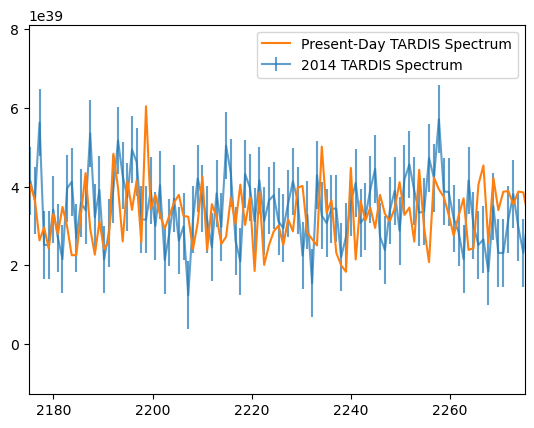

seed: 67584930


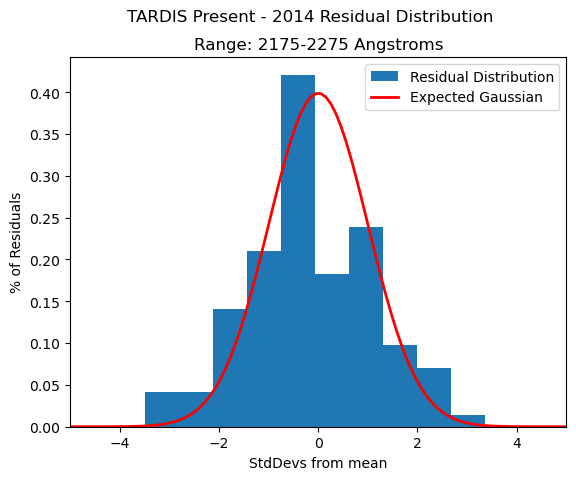

In [7]:
# Range 1

plt.xlim(start1, stop1)

plt.errorbar(spec_wavs_2014, spec_lums_2014, yerr=stddev1, label="2014 TARDIS Spectrum", zorder=0, alpha=0.7 )
plt.plot(spec_wavs_pres, spec_lums_pres, label="Present-Day TARDIS Spectrum", zorder=1)
plt.legend()
plt.show()

plt.xlabel("StdDevs from mean")
plt.ylabel("% of Residuals")
plt.hist(((spec_lums_pres[start1_index:stop1_index] - spec_lums_2014[start1_index:stop1_index])/(stddev1)), bins=10, density=True, label="Residual Distribution")

x = np.linspace(-5, 5, 100)
p = stats.norm.pdf(x, loc=0, scale=1) # Normal PDF
plt.plot(x, p, 'r', linewidth=2, label= "Expected Gaussian")

plt.legend(loc="upper right")
plt.suptitle("TARDIS Present - 2014 Residual Distribution")
plt.title("Range: 2175-2275 Angstroms")
plt.xlim(-5,5)
print("seed:", seed)
plt.show()


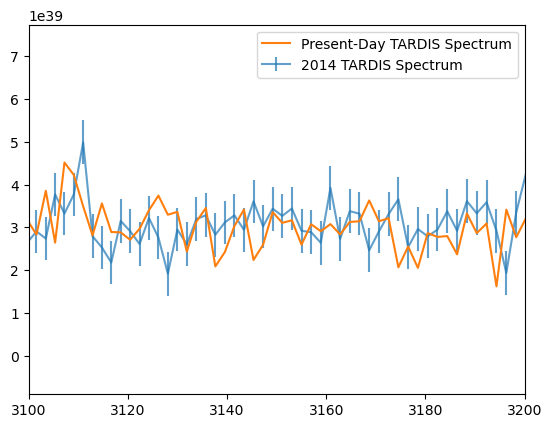

seed: 67584930


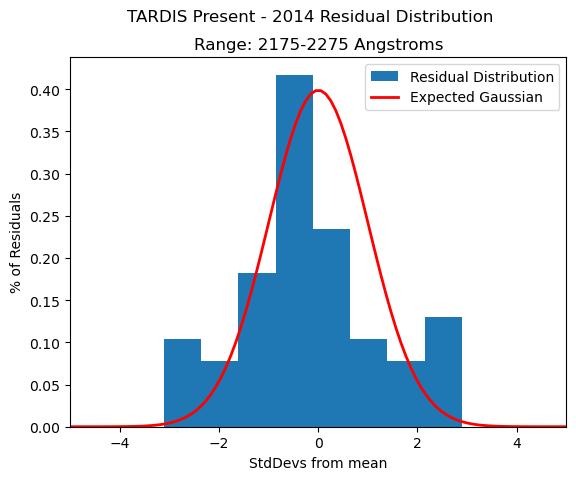

In [8]:
# Range 2

plt.xlim(start2, stop2)

plt.errorbar(spec_wavs_2014, spec_lums_2014, yerr=stddev2, label="2014 TARDIS Spectrum", alpha=0.7, zorder=0)
plt.plot(spec_wavs_pres, spec_lums_pres, label="Present-Day TARDIS Spectrum", zorder=1)
plt.legend()
plt.show()

plt.xlabel("StdDevs from mean")
plt.ylabel("% of Residuals")
plt.hist(((spec_lums_pres[start2_index:stop2_index] - spec_lums_2014[start2_index:stop2_index])/(stddev2)), bins=8, density=True, label="Residual Distribution")

x = np.linspace(-5, 5, 100)
p = stats.norm.pdf(x, loc=0, scale=1) # Normal PDF
plt.plot(x, p, 'r', linewidth=2, label= "Expected Gaussian")

plt.legend(loc="upper right")
plt.suptitle("TARDIS Present - 2014 Residual Distribution")
plt.title("Range: 2175-2275 Angstroms")
plt.xlim(-5,5)
print("seed:", seed)
plt.show()

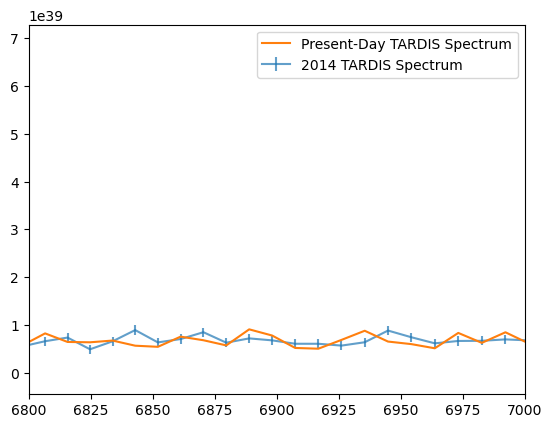

seed: 67584930


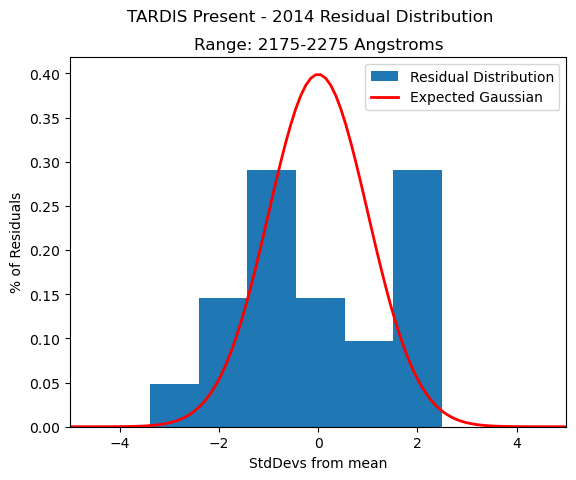

In [9]:
# Range 3

plt.xlim(start3, stop3)

plt.errorbar(spec_wavs_2014, spec_lums_2014, yerr=stddev3, label="2014 TARDIS Spectrum", alpha=0.7, zorder=0)
plt.plot(spec_wavs_pres, spec_lums_pres, label="Present-Day TARDIS Spectrum", zorder=1)
plt.legend()
plt.show()

plt.xlabel("StdDevs from mean")
plt.ylabel("% of Residuals")
plt.hist(((spec_lums_pres[start3_index:stop3_index] - spec_lums_2014[start3_index:stop3_index])/(stddev3)), bins=6, density=True, label="Residual Distribution")

x = np.linspace(-5, 5, 100)
p = stats.norm.pdf(x, loc=0, scale=1) # Normal PDF
plt.plot(x, p, 'r', linewidth=2, label= "Expected Gaussian")

plt.legend(loc="upper right")
plt.suptitle("TARDIS Present - 2014 Residual Distribution")
plt.title("Range: 2175-2275 Angstroms")
plt.xlim(-5,5)
print("seed:", seed)
plt.show()